**YOUR NAME HERE**

Spring 2026

CS 252: Mathematical Data Analysis and Visualization


In [18]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Project 2 | Linear Regression


## Task 0: Run a linear regression

In this task, you will implement linear regression using the built-in SciPy least-squares solver to determine the unknown coefficient vector $\vec{c}$ in the regression model $$\vec{y} = A\vec{c}$$ You will plot the results and focus on the Iris dataset.


### 0a. Import Iris data

1. In the below cell, load in the Iris dataset into a `Data` object.
2. Print out the object (only showing the first few data samples).
3. Create an `LinearRegression` object called `lin_reg` based on the `Data` object that you just created.


In [19]:
# YOUR CODE HERE
iris_data = data.Data(filepath='data/iris.csv')
print(iris_data)
lin_reg = linear_regression.LinearRegression(iris_data)

-------------------------------
data/iris.csv (150x5)
Headers:
  sepal_length	sepal_width	petal_length	petal_width	species
-------------------------------
Showing first 5/150 rows.
5.1	3.5	1.4	0.2	0.0
4.9	3.0	1.4	0.2	0.0
4.7	3.2	1.3	0.2	0.0
4.6	3.1	1.5	0.2	0.0
5.0	3.6	1.4	0.2	0.0

-------------------------------


Your code should print something that looks like this:

    -------------------------------
    data/iris.csv (150x5)
    Headers:
    sepal_length	sepal_width	petal_length	petal_width	species
    -------------------------------
    Showing first 5/150 rows.
    5.1	3.5	1.4	0.2	0.0
    4.9	3.0	1.4	0.2	0.0
    4.7	3.2	1.3	0.2	0.0
    4.6	3.1	1.5	0.2	0.0
    5.0	3.6	1.4	0.2	0.0


### 0b. Use SciPy's built-in least squares solver to perform linear regression

Implement the following methods to solve the regression model $$\vec{y} = A\vec{c}$$ for the unknown coefficient vector $\vec{c}$.

- `linear_regression_scipy`: Uses the built-in least squares solver in the `scipy` module to solve for the linear regression coefficients $\vec{c}$. **Run test code below.**
- `linear_regression`: This is the "front-facing" method to call if you want to do a linear regression. It calls `linear_regression_scipy` or another least squares solver method that you will soon implement to fit the linear regression coefficients. **Run test code below.**

Recall in the above equation:

- $A$ is the data matrix of independent variables selected for the regression shape=(`num_data_samps`, `num_ind_vars+1`) with an extra column of 1s tacked on for the intercept
- $\vec{c}$ is the vector of unknown regression coefficients associated with each independent variable (slopes + intercept) shape=(`num_ind_vars+1`, 1)
- $\vec{y}$ is the dependent variable column vector shape=(`num_data_samps`, 1)

**Tips:**

- The docstring for `linear_regression` instructs you to set all the instance variables. For now, focus on computing $\vec{c}$ (slopes and intercept) and put off computing $R^2$ and the residuals. Use the test code below to help you debug.


#### Test `linear_regression_scipy`


In [20]:
np.random.seed(0)
# test data: 10 data samples, 4 dimensional.
test_A = np.random.normal(size=(10, 4))
test_y = np.random.normal(size=(10, 1))
test_c = lin_reg.linear_regression_scipy(test_A, test_y)
print(f'Your regression fit coefficients are\n{np.squeeze(test_c)} and should be\n[ 0.10874  0.58024  0.05166 -0.34    -0.54393] OR\n[-0.54393  0.10874  0.58024  0.05166 -0.34   ]\n(depending on your preferred placement of the intercept)\n')
print(f'Your regression fit coefficient column vector shape is\n{test_c.shape} and should be\n(5, 1)')

Your regression fit coefficients are
[ 0.10874  0.58024  0.05166 -0.34    -0.54393] and should be
[ 0.10874  0.58024  0.05166 -0.34    -0.54393] OR
[-0.54393  0.10874  0.58024  0.05166 -0.34   ]
(depending on your preferred placement of the intercept)

Your regression fit coefficient column vector shape is
(5, 1) and should be
(5, 1)


#### Test `linear_regression` with one independent variable


In [21]:
lin_reg.linear_regression(['sepal_length'], 'petal_length')

print(f'Your regression fitted slope coefficients have shape\n{lin_reg.slope.shape}\nand the shape should be\n(1, 1)')
print(f'Your regression fitted slope coefficient is\n{lin_reg.slope[0, 0]:.4f}\nand it should be\n1.8584')
print(f'Your regression fitted intercept is\n{lin_reg.intercept:.4f}\nand it should be\n-7.1014')

Your regression fitted slope coefficients have shape
(1, 1)
and the shape should be
(1, 1)
Your regression fitted slope coefficient is
1.8584
and it should be
1.8584
Your regression fitted intercept is
-7.1014
and it should be
-7.1014


#### Test `linear_regression` with multiple independent variables


In [22]:
iris_headers = iris_data.get_headers()
lin_reg.linear_regression(iris_headers[:3], iris_headers[4])

print(f'Your regression fitted slope coefficients have shape\n{lin_reg.slope.shape}\nand the shape should be\n(3, 1)')
print(f'Your regression fitted slope coefficients are\n{lin_reg.slope[:, 0]}\nand it should be\n[-0.23818  0.09568  0.54794]')
print(f'Your regression fitted intercept is\n{lin_reg.intercept:.4f}\nand it should be\n0.0401')

Your regression fitted slope coefficients have shape
(3, 1)
and the shape should be
(3, 1)
Your regression fitted slope coefficients are
[-0.23818  0.09568  0.54794]
and it should be
[-0.23818  0.09568  0.54794]
Your regression fitted intercept is
0.0401
and it should be
0.0401


### 0c. Predict y values from fitted regression model

Implement the `predict` method: Use fitted linear regression model coefficients to make predictions based on the data.


#### Test `predict` with fitted data


In [23]:
iris_data_pred = data.Data(iris_filename)
iris_data_pred.limit_samples(100, 105)
iris_headers = iris_data_pred.get_headers()

lin_reg_pred = linear_regression.LinearRegression(iris_data_pred)
lin_reg_pred.linear_regression(iris_headers[:2], iris_headers[3])
y_pred = lin_reg_pred.predict()

print(f'Your model y predictions are\n{np.squeeze(y_pred)} and should be\n[2.48684 1.81579 2.06842 2.01316 2.11579]')
print(f'Your model y predictions shape is\n{y_pred.shape} and should be\n(5, 1)')

Your model y predictions are
[2.48684 1.81579 2.06842 2.01316 2.11579] and should be
[2.48684 1.81579 2.06842 2.01316 2.11579]
Your model y predictions shape is
(5, 1) and should be
(5, 1)


#### Test `predict` with novel data


In [24]:
np.random.seed(0)
# fake test data: 3 data samples, 4 dimensional.
test_slope = np.random.normal(size=(5, 1))
test_X = np.random.normal(size=(3, 5))
lin_reg.slope = test_slope
lin_reg.intercept = np.pi
y_pred = lin_reg.predict(test_X)
print(f'Your model y predictions are\n{np.squeeze(y_pred)} and should be\n[2.18518 5.82409 3.23376]')
print(f'Your model y predictions shape is\n{y_pred.shape} and should be\n(3, 1)')

Your model y predictions are
[2.18518 5.82409 3.23376] and should be
[2.18518 5.82409 3.23376]
Your model y predictions shape is
(3, 1) and should be
(3, 1)


### 0d. Compute linear regression statistics


Implement the following methods then call them from `linear_regression` to compute all the class instance variables from within `linear_regression`.

- `r_squared`: Quality of fit metric for linear regression. See $R^2$ equation below.
- `compute_residuals`: Compute the difference between the regression model predictions and the actual dependent variable values (residuals).
- `mse`: Computes the mean squared error in the predicted y compared the actual y values (see MSE equation below).

**$R^2$ Equation:** $$1 - \frac{E}{S}$$ where $$E = \sum_i \left (y_i - \hat{y}_i \right )^2$$ and $$S =  \sum_i \left (y_i - \bar{y} \right )^2$$ where $y_i$ are the dependent variable values, $\bar{y}_i$ is the mean of the dependent variable values, $\hat{y}_i$ is the y values _predicted_ by the regression.

**Equation for MSE:** $$MSE = \frac{1}{N}\sum_{i=1}^N \left (y_i - \hat{y}_i \right )^2$$


#### Test `linear_regression` method with $R^2$ and residuals


In [27]:
lin_reg.linear_regression(['sepal_length'], 'petal_width')

# test shapes of instance variables
print(f'Shape of your A data array is\n{lin_reg.A.shape} and should be\n(150, 1)')
print(f'Shape of your y dep var vector is\n{lin_reg.y.shape} and should be\n(150, 1)\n')
print(f"Your independent variables are:\n{lin_reg.ind_vars}\nand should be:\n['sepal_length']")
print(f'Your dependent variables are:\n{lin_reg.dep_var}\nand should be:\npetal_width\n')
print(f'Shape of your slope fits are {lin_reg.slope.shape} and should be (1, 1)')

# Test specific values
print(f'Your slope is {lin_reg.slope} and should be [[0.75292]]')
print(f'Your intercept is {lin_reg.intercept:.2f} and should be -3.20')
print(f'Your R^2 is {lin_reg.R2:.2f} and should be 0.67')
print(f'Your 1st few residuals are\n{lin_reg.residuals[:5].T} and should be\n[[-0.43966 -0.28908 -0.1385  -0.06321 -0.36437]]')

Shape of your A data array is
(150, 1) and should be
(150, 1)
Shape of your y dep var vector is
(150, 1) and should be
(150, 1)

Your independent variables are:
['sepal_length']
and should be:
['sepal_length']
Your dependent variables are:
petal_width
and should be:
petal_width

Shape of your slope fits are (1, 1) and should be (1, 1)
Your slope is [[0.75292]] and should be [[0.75292]]
Your intercept is -3.20 and should be -3.20
Your R^2 is 0.67 and should be 0.67
Your 1st few residuals are
[[-0.43966 -0.28908 -0.1385  -0.06321 -0.36437]] and should be
[[-0.43966 -0.28908 -0.1385  -0.06321 -0.36437]]


#### Test mean squared error (MSE)


In [28]:
# Test with iris data
lin_reg_norm = linear_regression.LinearRegression(iris_data)
lin_reg_norm.linear_regression(['sepal_length'], 'petal_width')
print(f'Your Iris MSE is {lin_reg_norm.compute_mse():.2f} and should be 0.19')

Your Iris MSE is 0.19 and should be 0.19


## Task 1: Visualize linear regression


### 1a. Update `scatter` to support visualizing linear regression results

Implement `scatter` in `linear_regression.py`: Call your `Analysis::scatter` method to make the scatter plot, then handle overlaying the regression line in `LinearRegression::scatter`. **Run test code below.**


#### Test `scatter` with linear regression

Only run this when you're done implementing all the methods thru `linear_regression`. This should produce:

1. A scatter plot with a linear regression line that looks like it makes sense.
2. The title should have the linear regression method ("scipy") and the $R^2$ value.


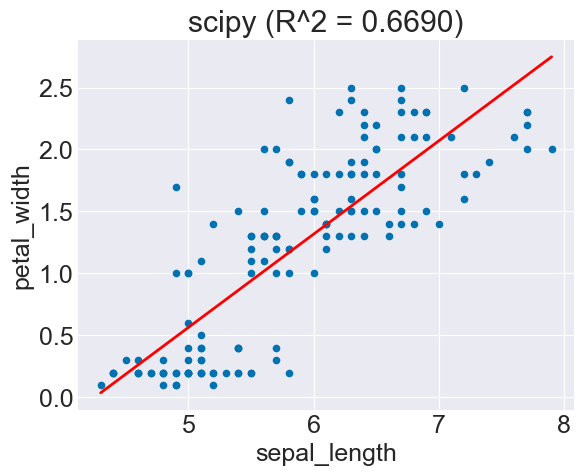

In [29]:
iris_filename = 'data/iris.csv'
iris_data = data.Data(iris_filename)
lin_reg = linear_regression.LinearRegression(iris_data)
lin_reg.linear_regression(['sepal_length'], 'petal_width')

lin_reg.scatter('sepal_length', 'petal_width', 'scipy')
lin_reg.show()

### 1b. Update `pair_plot` to add regression lines to each scatter plot


#### Test `pair_plot()`

Write `pair_plot()` in `linear_regression.py` that calls `Analysis::pair_plot` and extends it to compute and plot the regression line for each scatter plot (all pairs of variables). For now, you can ignore the keyword argument `hists_on_diag`. **Run test code below.**

Executing the cell below should produce:

- A 5x5 grid of scatter plots.
- (_new_) regression lines in each scatter plot. The title of each subplot should have the $R^2$ value.
- Only 1st column has y axis labels.
- Only last column has x axis labels.


(<Figure size 1200x1200 with 25 Axes>,
 array([[<Axes: title={'center': 'R^2 = 1.000'}, ylabel='sepal_length'>,
         <Axes: title={'center': 'R^2 = 0.014'}>,
         <Axes: title={'center': 'R^2 = 0.760'}>,
         <Axes: title={'center': 'R^2 = 0.669'}>,
         <Axes: title={'center': 'R^2 = 0.612'}>],
        [<Axes: title={'center': 'R^2 = 0.014'}, ylabel='sepal_width'>,
         <Axes: title={'center': 'R^2 = 1.000'}>,
         <Axes: title={'center': 'R^2 = 0.184'}>,
         <Axes: title={'center': 'R^2 = 0.134'}>,
         <Axes: title={'center': 'R^2 = 0.182'}>],
        [<Axes: title={'center': 'R^2 = 0.760'}, ylabel='petal_length'>,
         <Axes: title={'center': 'R^2 = 0.184'}>,
         <Axes: title={'center': 'R^2 = 1.000'}>,
         <Axes: title={'center': 'R^2 = 0.927'}>,
         <Axes: title={'center': 'R^2 = 0.901'}>],
        [<Axes: title={'center': 'R^2 = 0.669'}, ylabel='petal_width'>,
         <Axes: title={'center': 'R^2 = 0.134'}>,
         <Axes: ti

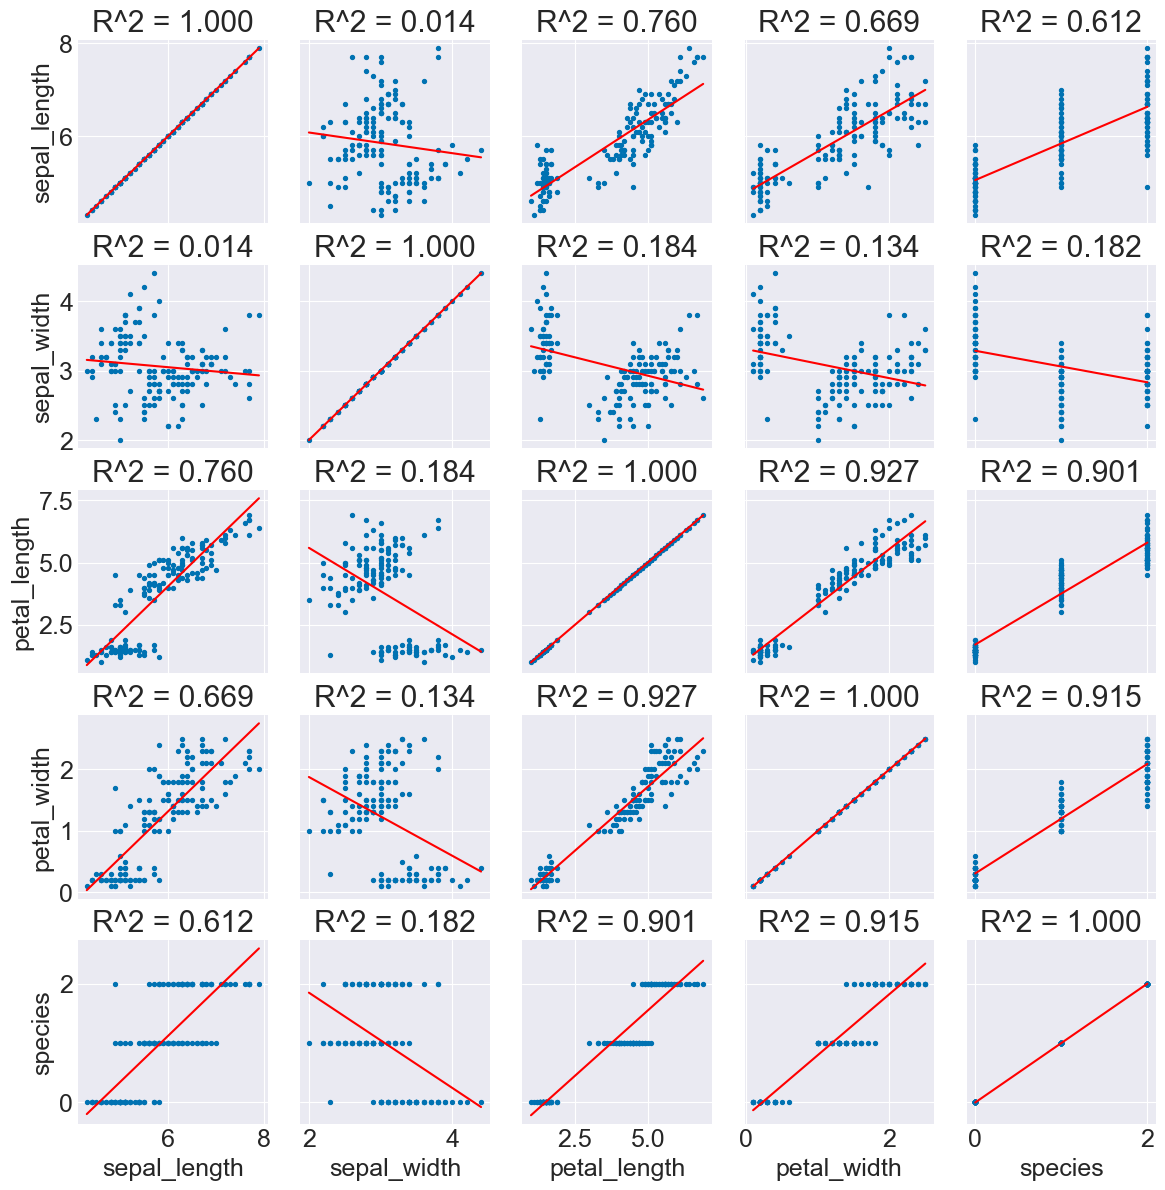

In [31]:
lin_reg.pair_plot(iris_data.get_headers(), hists_on_diag=False)

### 1c. Questions

**Question 1:** Not counting the categorical variable, use the pair plot to identify potential relationships among variables. Which variables appear to be most strongly related? Which variables appear least likely to be related?


**Answer 1:**
petal_length and petal_width are most strongly related, sepal_length and sepal_width are least likely related.


YOUR ANSWER HERE


### 1d. Adding histograms to `pair_plot`

Update your `pair_plot` code to place a histogram along the main diagonal of the `pair_plot` grid (rather than a scatter plot). Do this when the keyword argument `hists_on_diag` is set to `True`. Use (_or adapt_) the following code snippet right before plotting the histogram on row `i` and column `j` of your pair plot. _This code makes the x and y axis scaling different for the histograms (not shared with the scatter plots)_.

```python
numVars = len(data_vars)
axes[i, j].remove()
axes[i, j] = fig.add_subplot(numVars, numVars, i*numVars+j+1)
if j < numVars-1:
    axes[i, j].set_xticks([])
else:
    axes[i, j].set_xlabel(data_vars[i])
if i > 0:
    axes[i, j].set_yticks([])
else:
    axes[i, j].set_ylabel(data_vars[i])
```

Executing the cell below should produce:

- A 5x5 grid of scatter plots (histograms along main diagonal).
- Regression lines in each scatter plot. The title of each subplot should have the $R^2$ value.
- Only 1st column has y axis labels.
- Only last column has x axis labels.


(<Figure size 1200x1200 with 25 Axes>,
 array([[<Axes: title={'center': 'sepal_length'}, ylabel='sepal_length'>,
         <Axes: title={'center': 'R^2 = 0.014'}>,
         <Axes: title={'center': 'R^2 = 0.760'}>,
         <Axes: title={'center': 'R^2 = 0.669'}>,
         <Axes: title={'center': 'R^2 = 0.612'}>],
        [<Axes: title={'center': 'R^2 = 0.014'}, ylabel='sepal_width'>,
         <Axes: title={'center': 'sepal_width'}>,
         <Axes: title={'center': 'R^2 = 0.184'}>,
         <Axes: title={'center': 'R^2 = 0.134'}>,
         <Axes: title={'center': 'R^2 = 0.182'}>],
        [<Axes: title={'center': 'R^2 = 0.760'}, ylabel='petal_length'>,
         <Axes: title={'center': 'R^2 = 0.184'}>,
         <Axes: title={'center': 'petal_length'}>,
         <Axes: title={'center': 'R^2 = 0.927'}>,
         <Axes: title={'center': 'R^2 = 0.901'}>],
        [<Axes: title={'center': 'R^2 = 0.669'}, ylabel='petal_width'>,
         <Axes: title={'center': 'R^2 = 0.134'}>,
         <Axes: 

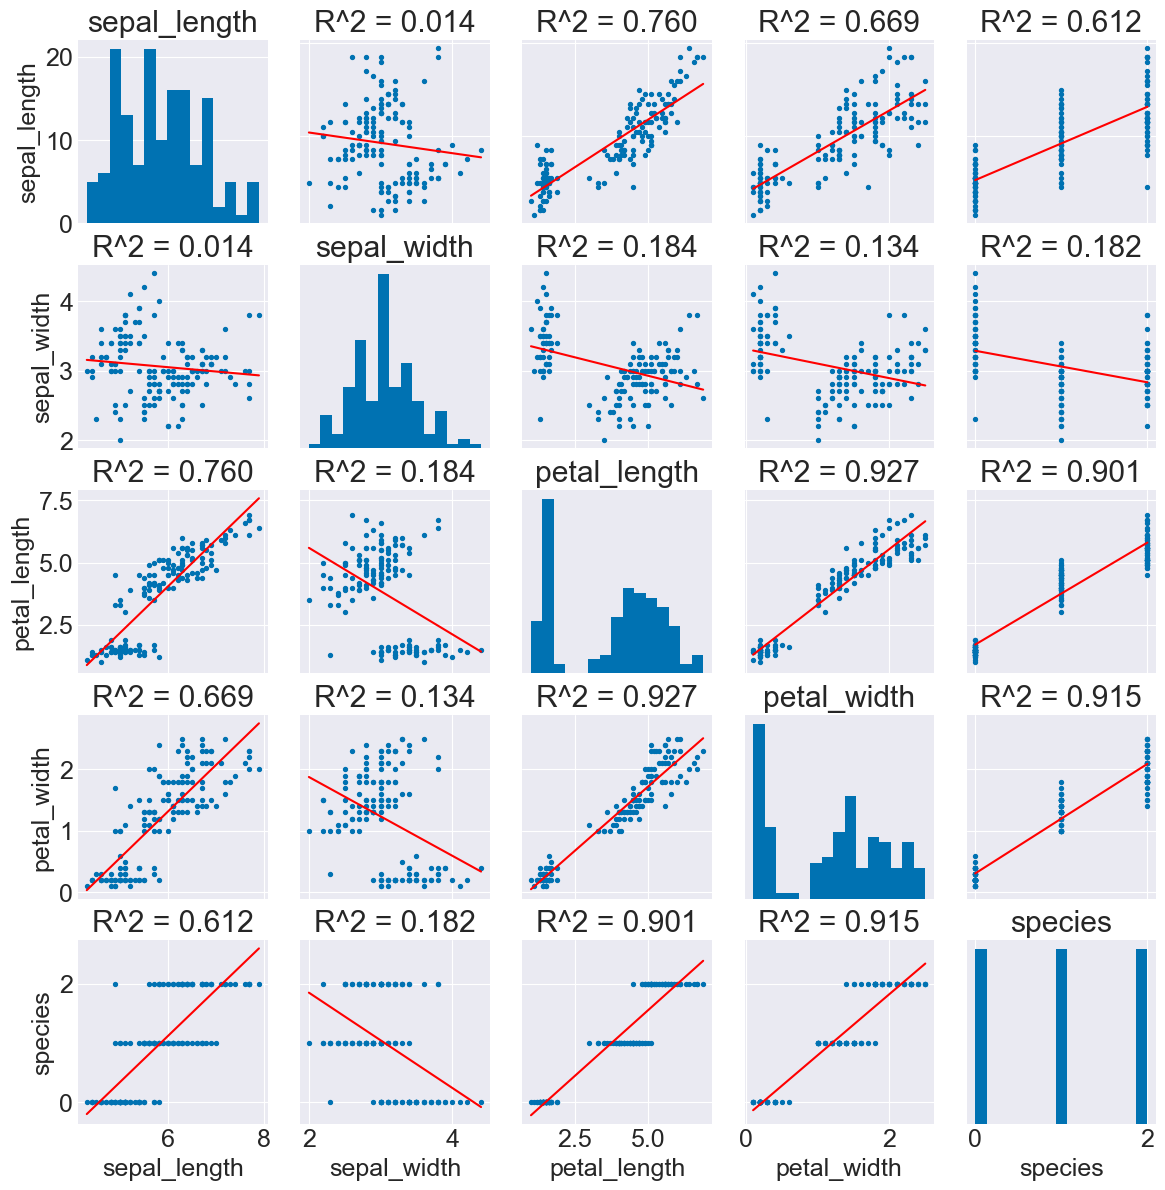

In [32]:
lin_reg.pair_plot(iris_data.get_headers(), hists_on_diag=True)

### 1e. Questions

**Question 2:** Make two observations about the dataset that the histograms help reveal.

**Question 3:** Blank question (_points on the house!_)


**Answer 2:**
petal_length and petal_width look multi-modal; sepal_width is more tightly concentrated around its centeer, while sepal_length is more spread out.


YOUR ANSWER HERE


## Task 2: Implement your own linear regression solver

In Tasks 0-1, you have used the SciPy least square solver to perform linear regression. In this task, you will solve the least squares problem directly using matrix math and compare the performance of the different methods on data.


### 2a. Normal equations

Implement the `linear_regression::linear_regression_normal` function. This method involves solving the normal equations $$(A^TA)\vec{c} = A^T\vec{y}$$

where:

- $A$ is the data matrix of independent variables selected for the regression shape=(`num_data_samps`, `num_ind_vars+1`) with an extra column of 1s tacked on for the intercept
- $\vec{c}$ is the vector of unknown regression coefficients associated with each independent variable (slopes + intercept) shape=(`num_ind_vars+1`, 1)
- $\vec{y}$ is the dependent variable column vector shape=(`num_data_samps`, 1)

In the cell below, perform a linear regression with `sepal_length` as the independent variable and `petal_width` as the dependent variable. Use your normal equations solver method by setting the `method` parameter below to the string `'normal'`. You should get the same results as with the SciPy solver above if everything is working as expected.


In [33]:
lin_reg_norm = linear_regression.LinearRegression(iris_data)
lin_reg_norm.linear_regression(['sepal_length'], 'petal_width', method='normal')

print('slope:', lin_reg_norm.slope)
print('intercept:', lin_reg_norm.intercept)
print('R^2:', lin_reg_norm.R2)

slope: [[0.75292]]
intercept: -3.2002150046492064
R^2: 0.6690276860464136
